<a href="https://colab.research.google.com/github/Sahil-y/Predictive-Maintenance-System/blob/main/notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv


Saving historical_data.csv to historical_data (2).csv


In [6]:
import os
print(os.listdir())

['.config', 'historical_data (2).csv', 'historical_data (1).csv', 'historical_data.csv', 'fear_greed_index.csv', 'fear_greed_index (1).csv', 'sample_data']


In [8]:
import pandas as pd
trader_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')

print("📊 Trader Data")
print(trader_df.head())

print("\n📊 Sentiment Data")
print(sentiment_df.head())

📊 Trader Data
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0        

In [10]:
print(trader_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [11]:
trader_df.columns = trader_df.columns.str.strip()


In [12]:
trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])
trader_df['date_only'] = trader_df['Timestamp'].dt.date

In [14]:
print(sentiment_df.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [15]:

sentiment_df.columns = sentiment_df.columns.str.strip()
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df['date'] = sentiment_df['date'].dt.date


In [16]:
trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])
trader_df['date_only'] = trader_df['Timestamp'].dt.date

In [17]:
merged_df = pd.merge(trader_df, sentiment_df, left_on='date_only', right_on='date', how='inner')


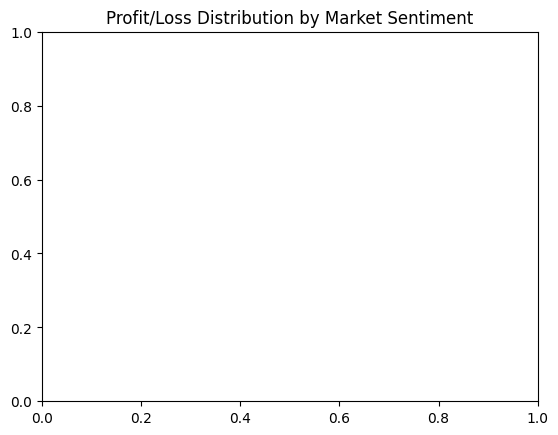

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged_df, x='classification', y='Closed PnL')
plt.title("Profit/Loss Distribution by Market Sentiment")
plt.show()


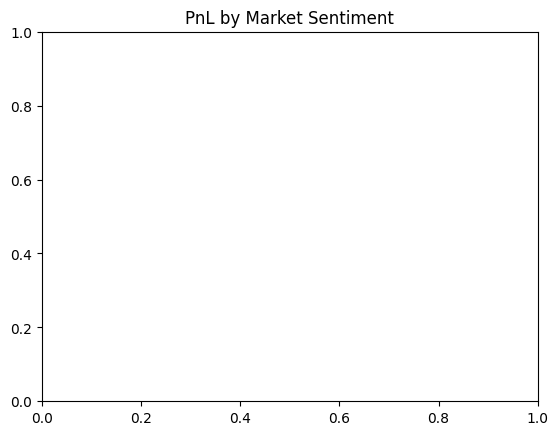

In [19]:
# Clean column names
trader_df.columns = trader_df.columns.str.strip()
sentiment_df.columns = sentiment_df.columns.str.strip()

# Convert to datetime
trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])
trader_df['date_only'] = trader_df['Timestamp'].dt.date

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df['date'] = sentiment_df['date'].dt.date

# Merge
merged_df = pd.merge(trader_df, sentiment_df, left_on='date_only', right_on='date', how='inner')

# Visualize
sns.boxplot(data=merged_df, x='classification', y='Closed PnL')
plt.title("PnL by Market Sentiment")
plt.show()

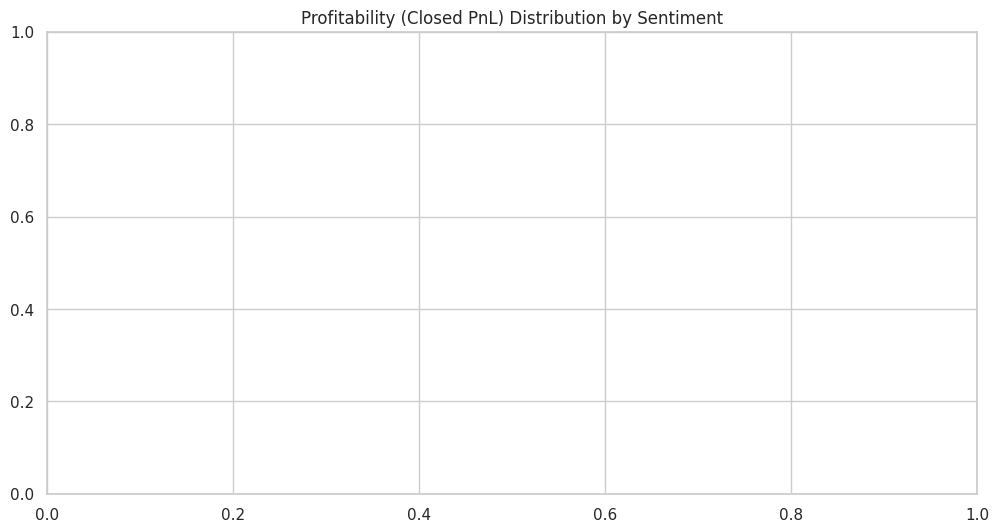

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.boxplot(data=merged_df, x='classification', y='Closed PnL')
plt.title("Profitability (Closed PnL) Distribution by Sentiment")
plt.show()


In [25]:
print(merged_df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date_only', 'timestamp', 'value', 'classification', 'date']


In [28]:
print(merged_df['size usd'].head(10))
print(merged_df['size usd'].isna().sum())  # How many missing values?

Series([], Name: size usd, dtype: float64)
0


In [29]:
  merged_df.columns = merged_df.columns.str.strip().str.lower()  # Clean column names
print(merged_df.columns.tolist())


['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp', 'date_only', 'timestamp', 'value', 'classification', 'date']


In [30]:
print(merged_df['size usd'].head(10))

Series([], Name: size usd, dtype: float64)


In [31]:
merged_df['size usd'] = pd.to_numeric(merged_df['size usd'], errors='coerce')
merged_df = merged_df.dropna(subset=['size usd'])

volume_by_sentiment = merged_df.groupby('classification')['size usd'].sum()

if not volume_by_sentiment.empty:
    volume_by_sentiment.plot(kind='bar', title='Total Volume by Market Sentiment')
    plt.ylabel("Volume (USD)")
    plt.xlabel("Market Sentiment")
    plt.show()
else:
    print("⚠️ No data found in 'size usd' after cleanup.")

⚠️ No data found in 'size usd' after cleanup.
